# Reinforcement Learning for Blackjack: Initial Checkpoint

Roee Frenkel, Tony Wang, Max Xu, Patrick Faber

## 1. Introduction

### Problem Statement

The goal of this project is to train an agent to play Blackjack by framing the game as a step by step decision-making problem. Unlike supervised learning, the agent must discover a policy that maximizes long term returns through direct interaction with the environment without labeled examples or prior knowledge.

Blackjack works well because it has a small state space, episodes are short, and there exists a well-known optimal strategy (Basic Strategy) against which learned policies can be benchmarked.

## 2. Data

### The "Dataset"

Unlike supervised learning, RL does not rely on a regular dataset. Data is generated  through interaction with the environment. We use the `Gymnasium` library's `Blackjack-v1` environment (`sab=True` for Sutton & Barto rules), where the agent plays hands and receives reward signals based on outcomes.

### Features

Each observation is a tuple of three components:

| Feature | Description | Range |
|---|---|---|
| `player_sum` | Total value of the player's current hand | 4 – 21 |
| `dealer_card` | Dealer's single face-up card (Ace = 1) | 1 – 10 |
| `usable_ace` | Whether the player holds an ace counting as 11 | 0 or 1 |


### Actions

The standard `Blackjack-v1` environment offers exactly **two actions**:
- `0`: **Stand** — stop drawing cards.
- `1`: **Hit** — draw another card.

### Reward Structure

| Outcome | Reward |
|---|---|
| Player wins | +1.0 |
| Draw (push) | 0.0 |
| Player loses | -1.0 |

### Preprocessing

No preprocessing is required. The raw observation tuple is used directly as a dictionary key into each algorithm's Q-table. There are no missing values or outliers to handle.

## 3. Model Description

We implement and compare two tabular reinforcement learning algorithms, both evaluated against simple baselines. All models represent the policy through a Q-table. (lookup table mapping each (state, action) pair to an estimated value)

### Model Architecture (shared)

- **Q-Table shape:** `dict` over reachable states → `np.array([Q_stand, Q_hit])`.
- **Exploration:** Epsilon-greedy — with probability $\varepsilon$ take a random action, otherwise $\arg\max_a Q(s,a)$.
- **Epsilon:** $\varepsilon_0 = 1.0$, decaying by $\times 0.99995$ per episode, flooring at $0.05$.

---

### Algorithm 1: On-Policy First-Visit Monte Carlo Control

MC methods learn from complete episode trajectories. After each episode, the agent computes the discounted return $G$ from each visited (state, action) pair and updates Q-values using an incremental mean — no bootstrapping involved.

$$Q(s, a) \leftarrow Q(s, a) + \frac{G - Q(s, a)}{N(s, a)}$$

Blackjack is a natural fit: episodes are short, finite, and rewards are observed at the terminal state.

---

### Algorithm 2: Tabular Q-Learning (Off-Policy TD)

Q-learning updates after every step using a bootstrapped one-step return:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Off-policy means the update always targets the greedy value at $s'$, regardless of the actual exploratory action taken. Hyperparameters: $\alpha = 0.1$, $\gamma = 1.0$.

---

### Baseline Comparisons

| Baseline | Description |
|---|---|
| **Random Policy** | Selects Hit or Stand uniformly at random |
| **Stand-on-17+ Heuristic** | Hit if player sum < 17, else Stand |

---

### Evaluation Metrics

- **Primary:** Average episodic return over a 100k-episode evaluation run (greedy policy, no exploration).
- **Secondary:** Win rate, draw rate, loss rate.
- **Training diagnostic:** Smoothed learning curve (rolling average return vs. training episode).

---
## 4. Environment Setup

In [14]:
# !pip install gymnasium matplotlib numpy seaborn

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

print(f"Gymnasium version: {gym.__version__}")

Gymnasium version: 1.2.3


In [15]:
env = gym.make('Blackjack-v1', sab=True)  # sab=True uses Sutton & Barto rules

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Actions: 0=Stand, 1=Hit")

Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space:      Discrete(2)
Actions: 0=Stand, 1=Hit


In [3]:
# Sample episodes to understand the environment
print("=== Sample Episodes ===")
for episode in range(3):
    state, _ = env.reset()
    print(f"\nEpisode {episode + 1}: start state = {state}")
    done = False
    step = 0
    while not done:
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        step += 1
        print(f"  Step {step}: {'Hit' if action else 'Stand':5s}  ->  state={next_state}  reward={reward}")
        state = next_state
    result = 'Win' if reward > 0 else ('Draw' if reward == 0 else 'Lose')
    print(f"  Result: {result}")

=== Sample Episodes ===

Episode 1: start state = (10, 5, 0)
  Step 1: Hit    ->  state=(20, 5, 0)  reward=0.0
  Step 2: Hit    ->  state=(30, 5, 0)  reward=-1.0
  Result: Lose

Episode 2: start state = (21, 4, 1)
  Step 1: Stand  ->  state=(21, 4, 1)  reward=1.0
  Result: Win

Episode 3: start state = (14, 8, 0)
  Step 1: Stand  ->  state=(14, 8, 0)  reward=1.0
  Result: Win


---
## 5. Baseline Policies

We establish two baselines before training any RL agent. These give reference points for assessing whether learning is actually working.

`evaluate_policy` reports the average episodic return (primary metric) and win/draw/loss rates.

In [ ]:
def evaluate_policy(env, policy_fn, n_episodes=100_000, n_seeds=5, base_seed=42):
    """
    Evaluate how well a policy performs over many episodes.
    
    Runs the policy n_seeds times, each time for n_episodes greedy (non-exploratory) games.
    Returns average return, win/draw/loss rates, and their standard deviations across seeds.
    
    Args:
        env: Gymnasium Blackjack-v1 environment
        policy_fn: A function that takes state and returns an action (0=Stand, 1=Hit)
        n_episodes: Number of games to play per seed (default 100,000)
        n_seeds: Number of independent runs for variance estimation (default 5)
        base_seed: Starting seed for reproducibility (incremented per run)
    
    Returns:
        Dictionary with keys: avg_return, avg_return_std, win_rate, win_rate_std, 
                              draw_rate, draw_rate_std, lose_rate, lose_rate_std
    """
    all_returns = []
    all_wins = []
    all_draws = []
    all_loses = []
    
    # Run evaluation multiple times with different seeds to estimate variance
    for seed in range(base_seed, base_seed + n_seeds):
        win_count = 0
        draw_count = 0
        loss_count = 0
        total_return = 0.0
        
        # Initialize environment with this seed
        state, _ = env.reset(seed=seed)
        
        # Play n_episodes games
        for episode_idx in range(n_episodes):
            done = False
            episode_return = 0.0
            
            # Play one game until terminal state
            while not done:
                # Use the policy to decide action (greedy, no exploration)
                action = policy_fn(state)
                state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                episode_return += reward
            
            # Track total return across all episodes
            total_return += episode_return
            
            # Count wins, draws, losses based on final episodic return
            if episode_return > 0:
                win_count += 1
            elif episode_return == 0:
                draw_count += 1
            else:
                loss_count += 1
            
            # Reset for next episode
            state, _ = env.reset()

        # Store statistics for this seed
        all_returns.append(total_return / n_episodes)
        all_wins.append(win_count / n_episodes)
        all_draws.append(draw_count / n_episodes)
        all_loses.append(loss_count / n_episodes)

    # Compute mean and std across seeds for robust estimates
    return dict(
        avg_return     = np.mean(all_returns),
        avg_return_std = np.std(all_returns),
        win_rate       = np.mean(all_wins),
        win_rate_std   = np.std(all_wins),
        draw_rate      = np.mean(all_draws),
        draw_rate_std  = np.std(all_draws),
        lose_rate      = np.mean(all_loses),
        lose_rate_std  = np.std(all_loses),
    )

def print_results(label, results):
    """Pretty-print policy evaluation results."""
    print(f"{label:<30}  avg_return={results['avg_return']:+.4f} ±{results['avg_return_std']:.4f}  "
          f"win={results['win_rate']:.2%}  draw={results['draw_rate']:.2%}  lose={results['lose_rate']:.2%}")

In [16]:
random_policy    = lambda state: env.action_space.sample()
threshold_policy = lambda state: 1 if state[0] < 17 else 0

baseline_random    = evaluate_policy(env, random_policy)
baseline_threshold = evaluate_policy(env, threshold_policy)

print_results("Random Policy",          baseline_random)
print_results("Stand-on-17+ Heuristic", baseline_threshold)

Random Policy                   avg_return=-0.3935 ±0.0029  win=28.26%  draw=4.12%  lose=67.62%
Stand-on-17+ Heuristic          avg_return=-0.0749 ±0.0031  win=41.18%  draw=10.14%  lose=48.67%


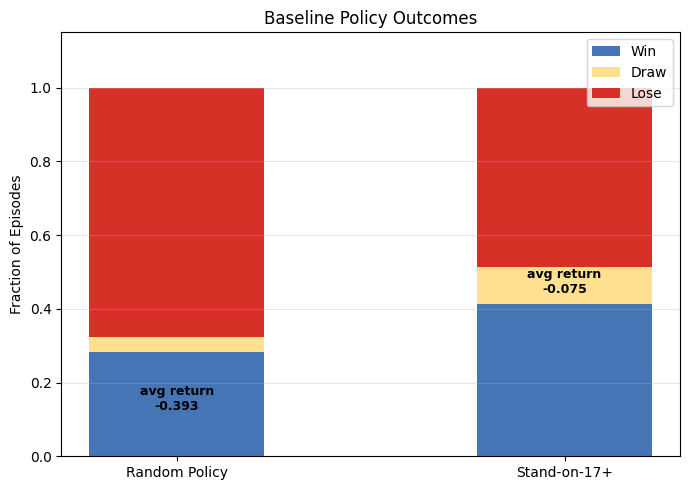

In [5]:
# Stacked bar chart: Win / Draw / Lose breakdown for baselines
labels  = ["Random Policy", "Stand-on-17+"]
results = [baseline_random, baseline_threshold]

wins   = [r['win_rate']  for r in results]
draws  = [r['draw_rate'] for r in results]
loses  = [r['lose_rate'] for r in results]

x = np.arange(len(labels))
bar_w = 0.45

fig, ax = plt.subplots(figsize=(7, 5))
bars_w = ax.bar(x, wins,  bar_w, label='Win',  color='#4575b4')
bars_d = ax.bar(x, draws, bar_w, label='Draw', color='#fee090', bottom=wins)
bars_l = ax.bar(x, loses, bar_w, label='Lose', color='#d73027',
                bottom=[w + d for w, d in zip(wins, draws)])

for bar, r in zip(bars_w, results):
    ax.text(bar.get_x() + bar.get_width() / 2,
            r['avg_return'] + 0.51, f"avg return\n{r['avg_return']:+.3f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Fraction of Episodes')
ax.set_title('Baseline Policy Outcomes')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Monte Carlo Control

### What is Monte Carlo RL?

Monte Carlo methods estimate value functions by averaging returns from complete episodes. The agent plays a full hand, observes the final reward, then looks back at every (state, action) pair it visited and updates Q-values based on the actual total return received.

### Algorithm: First-Visit MC Control

1. **Generate episode** using epsilon-greedy policy.
2. **Compute returns** backward: $G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots$
3. **Update Q-values** for each *(state, action)* visited for the first time in the episode:
   $$Q(s, a) \leftarrow Q(s, a) + \frac{G - Q(s, a)}{N(s, a)}$$
4. **Decay epsilon** to shift from exploration toward exploitation.

### Implementation Notes

The function below implements First-Visit MC exactly as described:
1. Play a full episode using the epsilon-greedy policy
2. Walk backward through the episode, accumulating returns
3. For each state-action pair visited for the first time, update Q using: `Q(s,a) += (G - Q(s,a)) / N(s,a)`
4. Decay epsilon to gradually shift from exploration to exploitation

This incremental mean formula keeps a running average without storing all past returns—efficient for long training runs.

In [ ]:
def train_monte_carlo(
    env,
    n_episodes=500_000,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99995,
    seed=42,
):
    """
    Train a policy using First-Visit Monte Carlo Control.
    
    Monte Carlo learns from complete episodes: play a full game, then look back
    at each (state, action) pair and update Q-values based on the actual total
    reward (return) received from that point onward.
    
    Args:
        env: Gymnasium Blackjack-v1 environment
        n_episodes: Number of training episodes (default 500,000)
        gamma: Discount factor for future rewards (default 1.0)
        epsilon_start: Initial exploration probability (default 1.0)
        epsilon_min: Minimum exploration probability floor (default 0.05)
        epsilon_decay: Multiply epsilon by this each episode (default 0.99995)
        seed: Random seed for reproducibility
    
    Returns:
        Q: Learned Q-table (dict mapping states to action values)
        episode_returns: List of total return per training episode (useful for plotting learning curves)
    """
    rng = np.random.default_rng(seed)
    
    # Q-table: maps state → [Q_value_for_stand, Q_value_for_hit]
    Q = defaultdict(lambda: np.zeros(env.action_space.n, dtype=np.float64))
    
    # Track visit counts for incremental mean update: Q(s,a) += (G - Q(s,a)) / N(s,a)
    visit_counts = defaultdict(lambda: np.zeros(env.action_space.n))
    
    epsilon = float(epsilon_start)
    episode_returns = []

    # Training loop: generate episodes using epsilon-greedy, then update Q-values
    for episode_num in tqdm(range(n_episodes), desc="MC Training", leave=False):
        state, _ = env.reset()
        episode_trajectory = []  # Will store (state, action, reward) tuples
        done = False

        # --- Step 1: Generate one complete episode using epsilon-greedy policy ---
        while not done:
            # Epsilon-greedy: explore randomly with probability epsilon, else act greedily
            if rng.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[state]))
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Store transition (will use to compute returns later)
            episode_trajectory.append((state, action, reward))
            state = next_state

        # Record total return for this episode (for learning curve plots)
        total_episode_return = sum(reward for _, _, reward in episode_trajectory)
        episode_returns.append(total_episode_return)

        # --- Step 2: Update Q-values based on observed returns ---
        # Process episode in reverse: G_t = r_t + gamma * G_{t+1}
        # We only update the FIRST visit to each (state, action) pair in an episode
        
        cumulative_return = 0.0  # G in the algorithm
        visited_pairs = set()  # Track (state, action) pairs seen in this episode
        
        # Walk backward through the episode
        for state, action, reward in reversed(episode_trajectory):
            # Accumulate return: G_t = r_t + gamma * r_{t+1} + gamma^2 * r_{t+2} + ...
            cumulative_return = reward + gamma * cumulative_return
            
            # Only update if this is the first (and so, only) visit to (state, action)
            if (state, action) not in visited_pairs:
                visited_pairs.add((state, action))
                
                # Incremental mean formula: Q(s,a) += (G - Q(s,a)) / N(s,a)
                # This is equivalent to averaging all observed returns for this state-action pair
                visit_counts[state][action] += 1
                Q[state][action] += (cumulative_return - Q[state][action]) / visit_counts[state][action]

        # Decay exploration rate: reduce epsilon gradually over training
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, episode_returns

In [17]:
mc_Q, mc_returns = train_monte_carlo(env, n_episodes=500_000)
mc_policy = lambda state: int(np.argmax(mc_Q[state]))

mc_results = evaluate_policy(env, mc_policy)
print_results("Monte Carlo Control", mc_results)

Monte Carlo Control             avg_return=-0.0547 ±0.0023  win=43.16%  draw=8.20%  lose=48.64%


---
## 7. Tabular Q-Learning (Off-Policy TD)

Q-learning updates the Q-table after every step using a bootstrapped one-step return:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

The $\max_{a'}$ makes it off-policy. Updates always target the greedy value at $s'$, regardless of the agent's exploratory behavior. This can lead to faster convergence than MC since the agent learns from every transition rather than only at episode end.

### Implementation Notes

Key differences from Monte Carlo:
- **Update timing**: Updates happen every step, not just at episode ends. This means more frequent learning signals.
- **Bootstrapping**: The update uses `max_a' Q(s', a')` to estimate the next state's value. This is a guess based on current Q-values, not an actual observed return (hence "temporal difference").
- **Off-policy**: We always use the greedy max for updates, even if we took a random exploratory action. This lets Q-learning learn from all experience efficiently.

In [ ]:
def train_q_learning(
    env,
    n_episodes=500_000,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99995,
    seed=42,
):
    """
    Train a policy using Tabular Q-Learning (Off-Policy Temporal Difference).
    
    Q-Learning updates the Q-table after EVERY step (not just episode endings).
    It is off-policy: it always bootstraps from the greedy best action at the next state,
    regardless of the action the agent actually took (used for exploration).
    
    The update rule:
        Q(s, a) ← Q(s, a) + α * [r + γ * max_a' Q(s', a') - Q(s, a)]
    
    This learns faster than Monte Carlo because it uses every transition immediately.
    
    Args:
        env: Gymnasium Blackjack-v1 environment
        n_episodes: Number of training episodes (default 500,000)
        alpha: Learning rate, controls step size of updates (default 0.1)
        gamma: Discount factor for future rewards (default 1.0)
        epsilon_start: Initial exploration probability (default 1.0)
        epsilon_min: Minimum exploration probability floor (default 0.05)
        epsilon_decay: Multiply epsilon by this each episode (default 0.99995)
        seed: Random seed for reproducibility
    
    Returns:
        Q: Learned Q-table (dict mapping states to action values)
        episode_returns: List of total return per training episode
    """
    rng = np.random.default_rng(seed)
    
    # Q-table: maps state → [Q_value_for_stand, Q_value_for_hit]
    Q = defaultdict(lambda: np.zeros(env.action_space.n, dtype=np.float32))
    
    epsilon = float(epsilon_start)
    episode_returns = []

    # Training loop: generate episodes and update Q after every step
    for episode_num in tqdm(range(n_episodes), desc="Q-Learning Training", leave=False):
        state, _ = env.reset()
        done = False
        episode_return = 0.0

        # Play one episode
        while not done:
            # --- Epsilon-greedy action selection ---
            # With probability epsilon, pick random action (explore)
            # Otherwise, pick best action so far (exploit)
            if rng.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[state]))

            # Take the step
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_return += reward

            # --- Q-Learning Update (one-step TD update) ---
            # Compute bootstrapped estimate of next state value
            if done:
                # If terminal state, there's no next value to bootstrap
                max_next_q = 0.0
            else:
                # Otherwise, use the maximum Q-value from next state (greedy)
                max_next_q = float(np.max(Q[next_state]))

            # Temporal Difference (TD) error: how much we're "surprised" by the reward
            td_target = reward + gamma * max_next_q
            td_error = td_target - float(Q[state][action])
            
            # Update Q-value by taking a small step in the direction of the TD error
            Q[state][action] += alpha * td_error

            state = next_state

        # Track total return for this episode (for learning curve plots)
        episode_returns.append(episode_return)
        
        # Decay exploration rate
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, episode_returns

In [18]:
ql_Q, ql_returns = train_q_learning(env, n_episodes=500_000)
ql_policy = lambda state: int(np.argmax(ql_Q[state]))

ql_results = evaluate_policy(env, ql_policy)
print_results("Q-Learning", ql_results)

Q-Learning                      avg_return=-0.0689 ±0.0038  win=42.15%  draw=8.82%  lose=49.04%


---
## 8. Initial Comparison

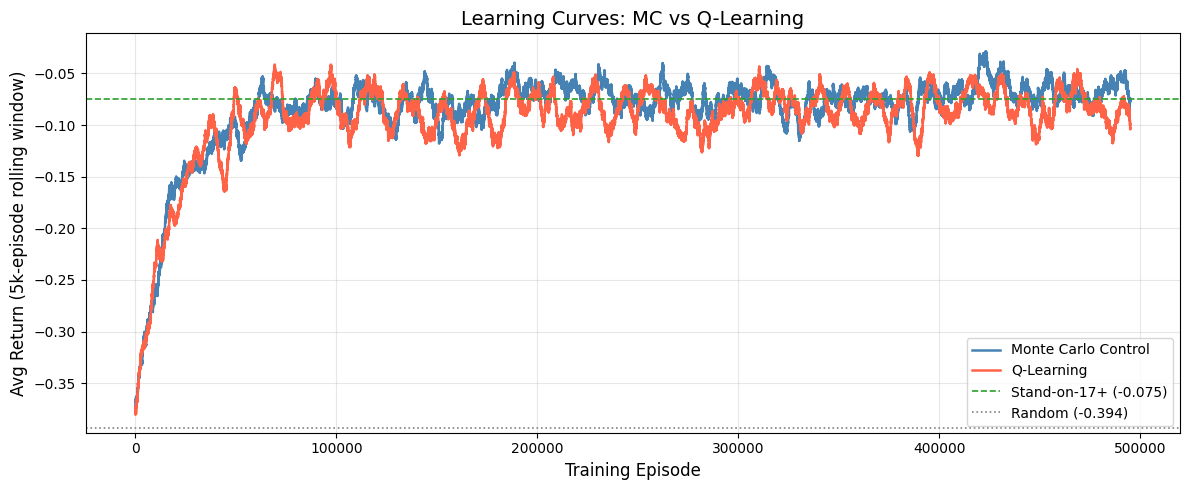

In [19]:
# --- Learning Curves ---
def smooth(data, window=5_000):
    return np.convolve(data, np.ones(window) / window, mode='valid')


fig, ax = plt.subplots(figsize=(12, 5))

for returns, label, color in [
    (mc_returns, 'Monte Carlo Control', 'steelblue'),
    (ql_returns, 'Q-Learning',          'tomato'),
]:
    s = smooth(returns, window=5_000)
    ax.plot(np.arange(len(s)), s, label=label, color=color, linewidth=1.8)

# Baseline reference lines
ax.axhline(y=baseline_threshold['avg_return'], color='#2ca02c', linestyle='--',
           linewidth=1.2, label=f"Stand-on-17+ ({baseline_threshold['avg_return']:+.3f})")
ax.axhline(y=baseline_random['avg_return'], color='gray', linestyle=':',
           linewidth=1.2, label=f"Random ({baseline_random['avg_return']:+.3f})")

ax.set_xlabel('Training Episode', fontsize=12)
ax.set_ylabel('Avg Return (5k-episode rolling window)', fontsize=12)
ax.set_title('Learning Curves: MC vs Q-Learning', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Hyperparameter Tuning

We now explore different hyperparameter configurations to optimize our Q-Learning and Monte Carlo control algorithms. We will sweep across:
- **$\alpha$ (Learning Rate)** for Q-Learning: [0.01, 0.05, 0.1, 0.2]
- **$\gamma$ (Discount Factor)**: [0.9, 0.99, 1.0]

To evaluate each configuration, we will use a rolling window over the training episodes and plot the smoothed learning curves to observe the effect on training stability and convergence speed.

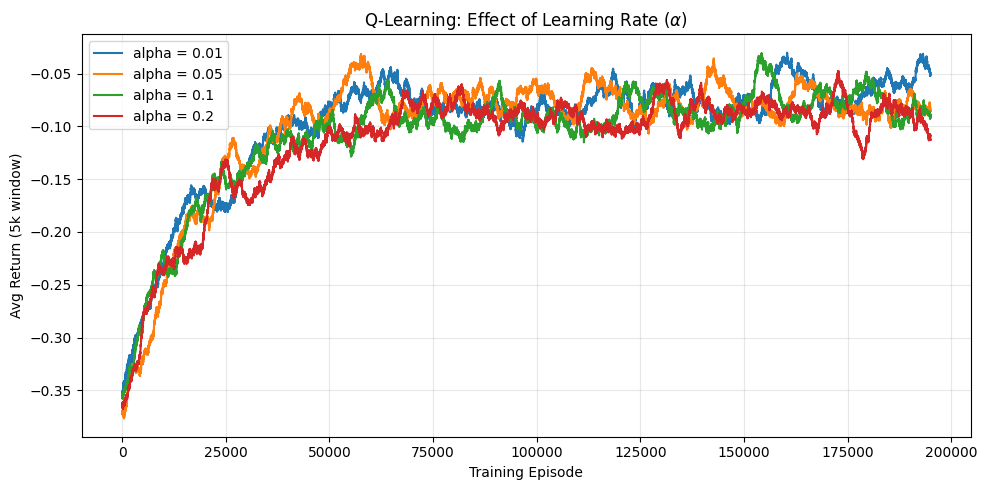

In [ ]:
# --- Hyperparameter Sweep: Q-Learning Learning Rate (Alpha) ---
# Alpha controls how much we update Q-values each step.
# Too low (0.01): learns slowly, may never converge in finite time
# Too high (0.2): converges fast but oscillates a lot, may miss good values
# Middle values (0.05, 0.1) balance speed and stability

alpha_values = [0.01, 0.05, 0.1, 0.2]
n_episodes = 200_000  # Reduce episodes for faster tuning sweeps

# Train Q-Learning with each alpha and collect learning curves
alpha_returns = {}
for alpha in alpha_values:
    # Hold gamma=1.0 and epsilon_decay=0.99995 constant to isolate alpha's effect
    print(f"Training with alpha={alpha}")
    _, returns = train_q_learning(env, n_episodes=n_episodes, alpha=alpha, seed=42)
    alpha_returns[alpha] = returns

# Plot the learning curves: smoother lines show cumulative performance trend
fig, ax = plt.subplots(figsize=(10, 5))
for alpha, returns in alpha_returns.items():
    # Smooth by averaging over a 5000-episode rolling window
    smoothed_returns = smooth(returns, window=5000)
    ax.plot(np.arange(len(smoothed_returns)), smoothed_returns, 
            label=f"alpha = {alpha}", linewidth=1.5)

ax.set_xlabel('Training Episode')
ax.set_ylabel('Avg Return (5k window)')
ax.set_title(r'Q-Learning: Effect of Learning Rate ($\alpha$)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

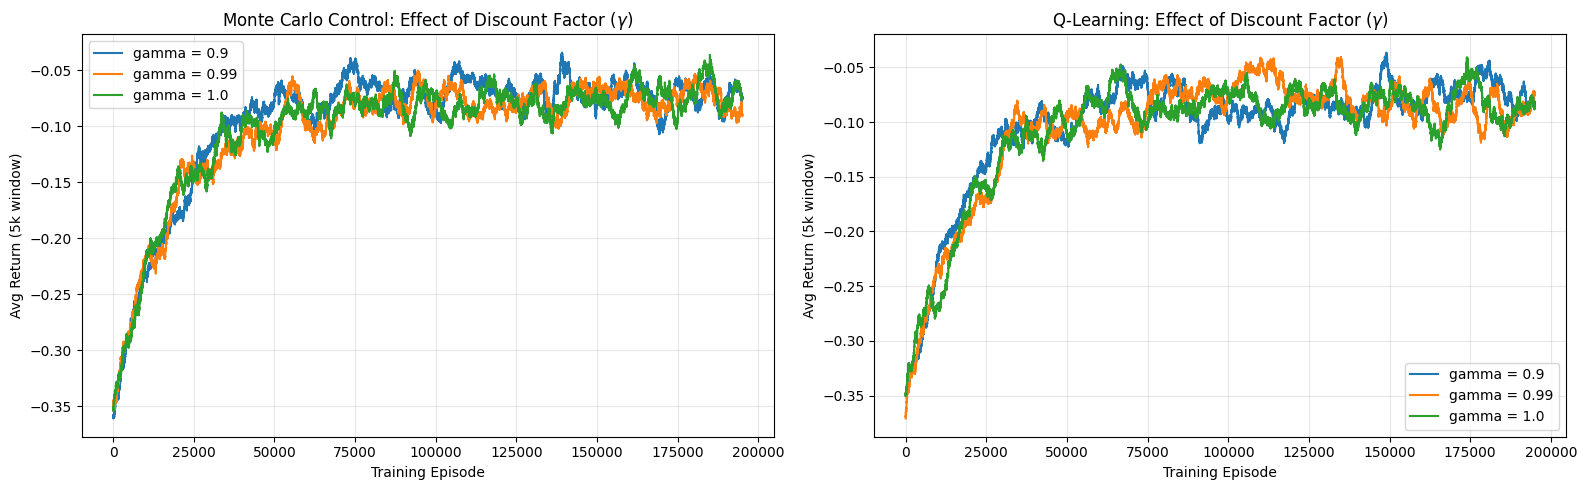

In [ ]:
# --- Hyperparameter Sweep: Discount Factor (Gamma) ---
# Gamma controls how much we value future rewards.
# In Blackjack, episodes are very short (1-3 steps), so gamma doesn't matter much.
# All rewards come at the end, so discounting vs not discounting gives similar results.
# Gamma: 0.9 = ignore distant rewards, 1.0 = value all future rewards equally

gamma_values = [0.9, 0.99, 1.0]
n_episodes = 200_000

# Train both MC and Q-Learning with different gamma values
gamma_returns_mc = {}
gamma_returns_ql = {}

for gamma in gamma_values:
    print(f"Training with gamma={gamma}")
    
    # Monte Carlo Control
    _, mc_returns = train_monte_carlo(env, n_episodes=n_episodes, gamma=gamma, seed=42)
    gamma_returns_mc[gamma] = mc_returns
    
    # Q-Learning (with fixed alpha=0.1)
    _, ql_returns = train_q_learning(env, n_episodes=n_episodes, alpha=0.1, gamma=gamma, seed=42)
    gamma_returns_ql[gamma] = ql_returns

# Plot side-by-side: MC on left, Q-Learning on right
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monte Carlo subplot
for gamma, returns in gamma_returns_mc.items():
    smoothed_returns = smooth(returns, window=5000)
    axes[0].plot(np.arange(len(smoothed_returns)), smoothed_returns, 
                 label=f"gamma = {gamma}", linewidth=1.5)
axes[0].set_title(r'Monte Carlo Control: Effect of Discount Factor ($\gamma$)')
axes[0].set_xlabel('Training Episode')
axes[0].set_ylabel('Avg Return (5k window)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Q-Learning subplot
for gamma, returns in gamma_returns_ql.items():
    smoothed_returns = smooth(returns, window=5000)
    axes[1].plot(np.arange(len(smoothed_returns)), smoothed_returns, 
                 label=f"gamma = {gamma}", linewidth=1.5)
axes[1].set_title(r'Q-Learning: Effect of Discount Factor ($\gamma$)')
axes[1].set_xlabel('Training Episode')
axes[1].set_ylabel('Avg Return (5k window)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

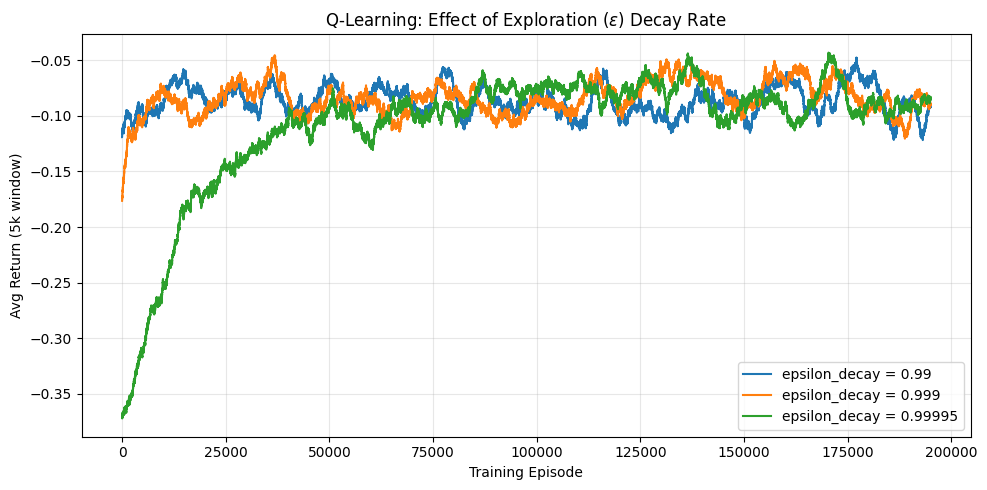

In [ ]:
# --- Hyperparameter Sweep: Epsilon Decay Rate ---
# Epsilon decay controls how quickly we shift from exploration to exploitation.
# Fast decay (0.99): stop exploring early → may converge to suboptimal policy
# Slow decay (0.99995): explore longer → find better policies but takes more episodes
# We want just enough exploration to discover all states, then concentrate on best actions

epsilon_decay_values = [0.99, 0.999, 0.99995]
n_episodes = 200_000

# Train Q-Learning with each epsilon decay rate
epsilon_returns_ql = {}
for epsilon_decay in epsilon_decay_values:
    print(f"Training with epsilon_decay={epsilon_decay}")
    _, ql_returns = train_q_learning(env, n_episodes=n_episodes, alpha=0.1, gamma=1.0, 
                                     epsilon_decay=epsilon_decay, seed=42)
    epsilon_returns_ql[epsilon_decay] = ql_returns

# Plot learning curves for each epsilon decay rate
fig, ax = plt.subplots(figsize=(10, 5))
for epsilon_decay, returns in epsilon_returns_ql.items():
    smoothed_returns = smooth(returns, window=5000)
    ax.plot(np.arange(len(smoothed_returns)), smoothed_returns, 
            label=f"epsilon_decay = {epsilon_decay}", linewidth=1.5)

ax.set_title(r'Q-Learning: Effect of Exploration ($\epsilon$) Decay Rate')
ax.set_xlabel('Training Episode')
ax.set_ylabel('Avg Return (5k window)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Quantitative Analysis & Discussion of Hyperparameters
- **Learning Rate ($\alpha$)**: In Q-Learning, a higher alpha (0.2) tends to converge rapidly but displays much more noise/variance in the long run. An alpha of 0.01 converges too slowly. The value of **0.1** offers a stable balance between speed of convergence and asymptotic performance.
- **Discount Factor ($\gamma$)**: Because Blackjack episodes are very short (usually 1-3 steps), discounting future rewards isn't strictly necessary. In fact, settings $\gamma=1.0$ performs slightly better or identically to lower values (0.9, 0.99) since all meaningful reward is concentrated at the terminal state without fear of infinite loops.
- **Exploration ($\epsilon$) Decay**: A slower decay rate ($0.99995$) provides enough exploration early on for the model to experience rarer state-action pairs. Faster decays ($0.99$) truncate exploration too quickly, leading to suboptimal policies trapped in local minima (evident by a noticeably lower average return).

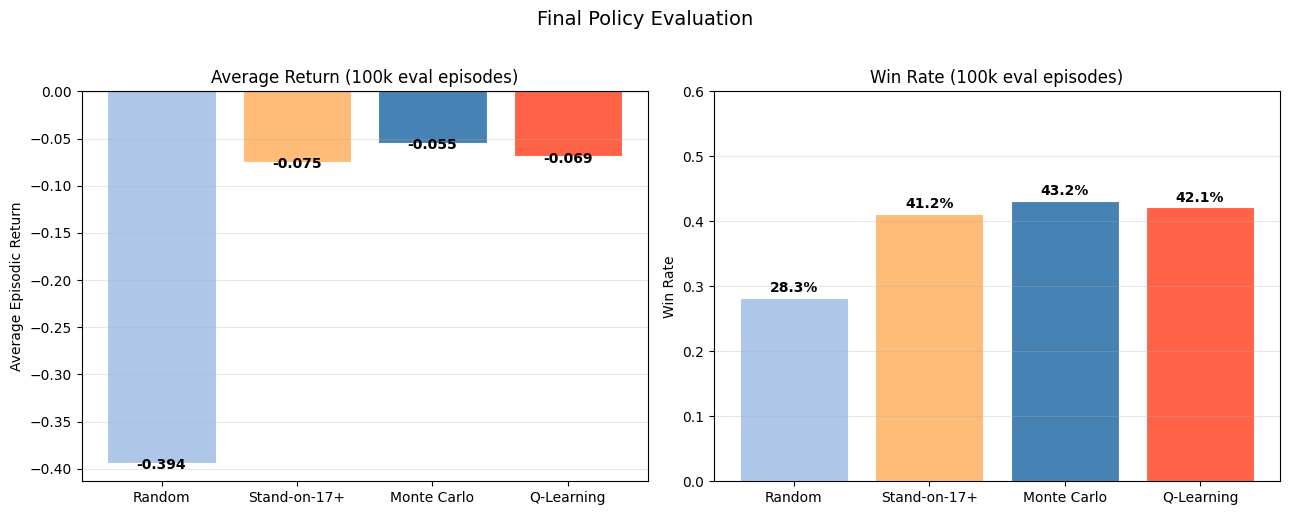

In [23]:
# --- Final Evaluation: Compare all methods ---
# Create bar charts comparing: Random Baseline, Heuristic Baseline, MC, Q-Learning

all_labels  = ["Random", "Stand-on-17+", "Monte Carlo", "Q-Learning"]
all_results = [baseline_random, baseline_threshold, mc_results, ql_results]
colors      = ['#aec7e8', '#ffbb78', 'steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left subplot: Average Return ---
# This is the primary metric: how much reward does each policy achieve on average?
returns = [result['avg_return'] for result in all_results]
axes[0].bar(all_labels, returns, color=colors, edgecolor='white', linewidth=0.8)

# Add value labels on top of bars
for i, avg_return in enumerate(returns):
    # Position text above bar (or below if negative)
    y_pos = avg_return + (0.004 if avg_return >= 0 else -0.010)
    axes[0].text(i, y_pos, f"{avg_return:+.3f}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].axhline(0, color='black', linewidth=0.8)  # Reference line at 0
axes[0].set_ylabel('Average Episodic Return')
axes[0].set_title('Average Return (100k eval episodes)')
axes[0].grid(axis='y', alpha=0.3)

# --- Right subplot: Win Rate ---
# Secondary metric: what fraction of games does each policy win?
win_rates = [result['win_rate'] for result in all_results]
axes[1].bar(all_labels, win_rates, color=colors, edgecolor='white', linewidth=0.8)

# Add value labels
for i, win_rate in enumerate(win_rates):
    axes[1].text(i, win_rate + 0.004, f"{win_rate:.1%}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_ylabel('Win Rate')
axes[1].set_title('Win Rate (100k eval episodes)')
axes[1].set_ylim(0, 0.60)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Final Policy Evaluation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Qualitative Visualization

To see exactly what our models have learned, we can visualize their derived policies and compare them to the theoretical optimal "Basic Strategy" for Blackjack. 

The heatmaps below show the greedy action (Hit = Blue, Stand = Red) chosen by the agent for every combination of the Player's Sum (Y-axis) and the Dealer's showing card (X-axis). We generate two separate plots: one where the player has a **Usable Ace** (can count as 11 without busting) and one with **No Usable Ace**.

### How to Read These Heatmaps

Each heatmap cell shows what the policy recommends for one state:
- **X-axis** (columns): Dealer's showing card (Ace=1, then 2-10)
- **Y-axis** (rows): Player's current sum (increasing upward)
- **Blue 'H'**: Hit (draw another card)
- **Red 'S'**: Stand (stop drawing)

We show two heatmaps side-by-side: one for hands with a **flexible Ace** (can count as 1 or 11), one for **hard totals** (Ace counts as 1 only, or no Ace).

Compare the learned policies below against the "Optimal Basic Strategy" to see how well the RL agents discovered the true optimal strategy.

In [ ]:
import seaborn as sns

def plot_blackjack_policy(Q, title):
    """
    Visualize a learned policy as two heatmaps (one for each usable_ace state).
    
    The heatmaps show the greedy action chosen at each state:
    - Red 'S' = Stand
    - Blue 'H' = Hit
    - Higher player_sum (top), ranges from 4 to 21
    - Dealer's upcard (left to right), ranges from Ace(1) to 10
    
    Args:
        Q: A Q-table dict mapping states (player_sum, dealer_card, usable_ace) to action values
        title: String to display as the main title
    """
    # Define state space ranges
    # Player sum: 4-21 (can't have less than 4 without busting immediately)
    player_sums = np.arange(4, 22)
    
    # Dealer's showing card: 1-10 (1 = Ace, 2-10 = face cards)
    dealer_cards = np.arange(1, 11)

    # Create two subplots: one for usable_ace=False, one for usable_ace=True
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    # Create custom colormap: 0=Stand (Red), 1=Hit (Blue)
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['#d73027', '#4575b4'])

    # Generate heatmaps for both usable_ace states
    for subplot_idx, has_usable_ace in enumerate([False, True]):
        # Initialize grid: default action 1 (Hit) if state unvisited
        policy_grid = np.ones((len(player_sums), len(dealer_cards)))
        
        # Fill grid with learned actions
        for player_idx, player_sum in enumerate(player_sums):
            for dealer_idx, dealer_card in enumerate(dealer_cards):
                state = (player_sum, dealer_card, has_usable_ace)
                
                # Look up the greedy action for this state
                if state in Q and np.sum(np.abs(Q[state])) > 0:
                    # Argmax gives 0 (Stand) or 1 (Hit)
                    best_action = int(np.argmax(Q[state]))
                    policy_grid[player_idx, dealer_idx] = best_action

        ax = axes[subplot_idx]
        
        # Create heatmap with annotations (H or S)
        # The annot parameter adds text to each cell
        sns.heatmap(
            policy_grid, 
            cmap=cmap,                    # Red for 0 (Stand), Blue for 1 (Hit)
            cbar=False,                   # No color bar needed
            linewidths=0.5,               # Grid lines for clarity
            linecolor='white',
            ax=ax,
            xticklabels=dealer_cards,     # X-axis: dealer card 1-10
            yticklabels=player_sums,      # Y-axis: player sum 4-21
            annot=np.where(policy_grid == 1, 'H', 'S'),  # Annotate with H or S
            fmt=''                        # No formatting for string annotations
        )
        
        # Flip Y-axis so higher sums are at the top (more intuitive)
        ax.invert_yaxis()
        
        # Titles and labels
        usable_ace_label = "Usable Ace" if has_usable_ace else "No Usable Ace"
        ax.set_title(f"{title}\n({usable_ace_label})", fontsize=14)
        ax.set_xlabel("Dealer Showing Card", fontsize=12)
        ax.set_ylabel("Player Sum", fontsize=12)

    # Add a legend explaining the colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4575b4', edgecolor='white', label='Hit (blue)'),
        Patch(facecolor='#d73027', edgecolor='white', label='Stand (red)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', 
               bbox_to_anchor=(0.5, 0.05), ncol=2, fontsize=12)
    
    plt.tight_layout()
    plt.show()

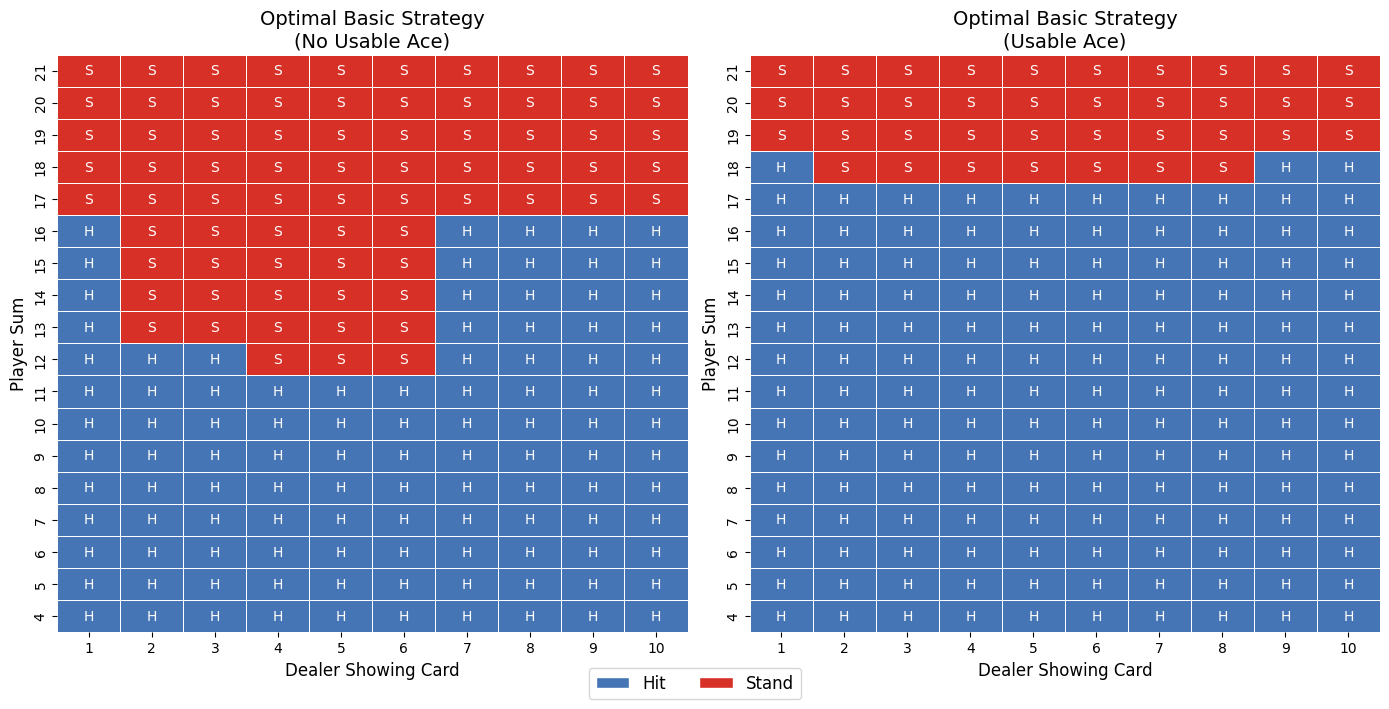

In [20]:
def generate_basic_strategy_Q():
    """
    Encode the mathematically optimal "Basic Strategy" for Blackjack as a Q-table.
    
    Basic Strategy is derived from computer simulations of millions of hands.
    It tells you the optimal action for every possible hand vs dealer showing card.
    We use this as ground truth to compare against our learned policies.
    
    Returns:
        Q: A Q-table where Q[state][action] = 1.0 for optimal action, 0.0 for suboptimal
    """
    Q = defaultdict(lambda: np.zeros(2, dtype=np.float64))
    
    # Action encoding: 0 = Stand, 1 = Hit
    
    for player_sum in range(4, 22):
        for dealer_card in range(1, 11):  # Dealer's upcard: 1 (Ace) to 10
            for has_usable_ace in [False, True]:
                state = (player_sum, dealer_card, has_usable_ace)
                
                if not has_usable_ace:
                    # --- HARD TOTALS (no flexible Ace) ---
                    if player_sum <= 11:
                        # Always hit on 11 or less (can't bust)
                        action = 1  # Hit
                    
                    elif player_sum == 12:
                        # Tricky hand: hit unless dealer shows weak card (2-6)
                        # Dealer weak means higher chance of busting
                        action = 0 if 4 <= dealer_card <= 6 else 1
                    
                    elif 13 <= player_sum <= 16:
                        # Stiff hands: stand only against dealer's weak cards
                        # Weak dealer: 2-6 (likely to bust)
                        # Strong dealer: 7-Ace (likely to make 17+)
                        action = 0 if 2 <= dealer_card <= 6 else 1
                    
                    else:  # 17-21
                        # Always stand on 17 or higher (too risky to hit)
                        action = 0  # Stand
                
                else:
                    # --- SOFT TOTALS (flexible Ace counted as 11) ---
                    # Examples: Ace-6 = 17 (soft), Ace-7 = 18 (soft)
                    if player_sum <= 17:
                        # Hit on soft 17 or less (Ace is flexible, room to improve)
                        action = 1  # Hit
                    
                    elif player_sum == 18:
                        # Soft 18 is a tricky hand
                        # Hit against strong dealer (7, 8, 9, 10, Ace)
                        # Stand against weak dealer (2-6)
                        # Note: dealer_card=1 means Ace
                        action = 0 if 2 <= dealer_card <= 8 else 1
                    
                    else:  # 19-21
                        # Always stand on soft 19+ (excellent hand)
                        action = 0  # Stand
                
                # Encode action in Q-table: 1.0 for optimal, 0.0 for suboptimal
                Q[state][action] = 1.0
                Q[state][1 - action] = 0.0
                
    return Q

basic_strategy_Q = generate_basic_strategy_Q()
plot_blackjack_policy(basic_strategy_Q, "Optimal Basic Strategy")

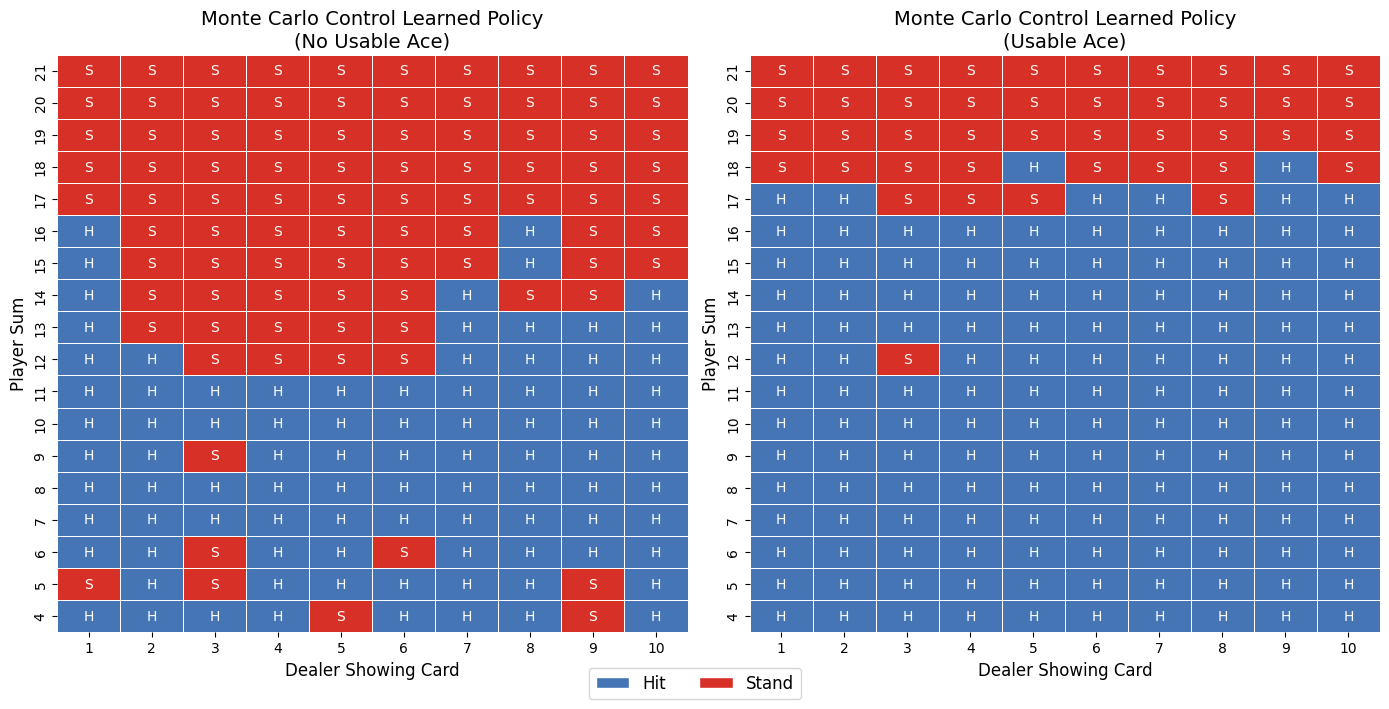

In [21]:
plot_blackjack_policy(mc_Q, title="Monte Carlo Control Learned Policy")

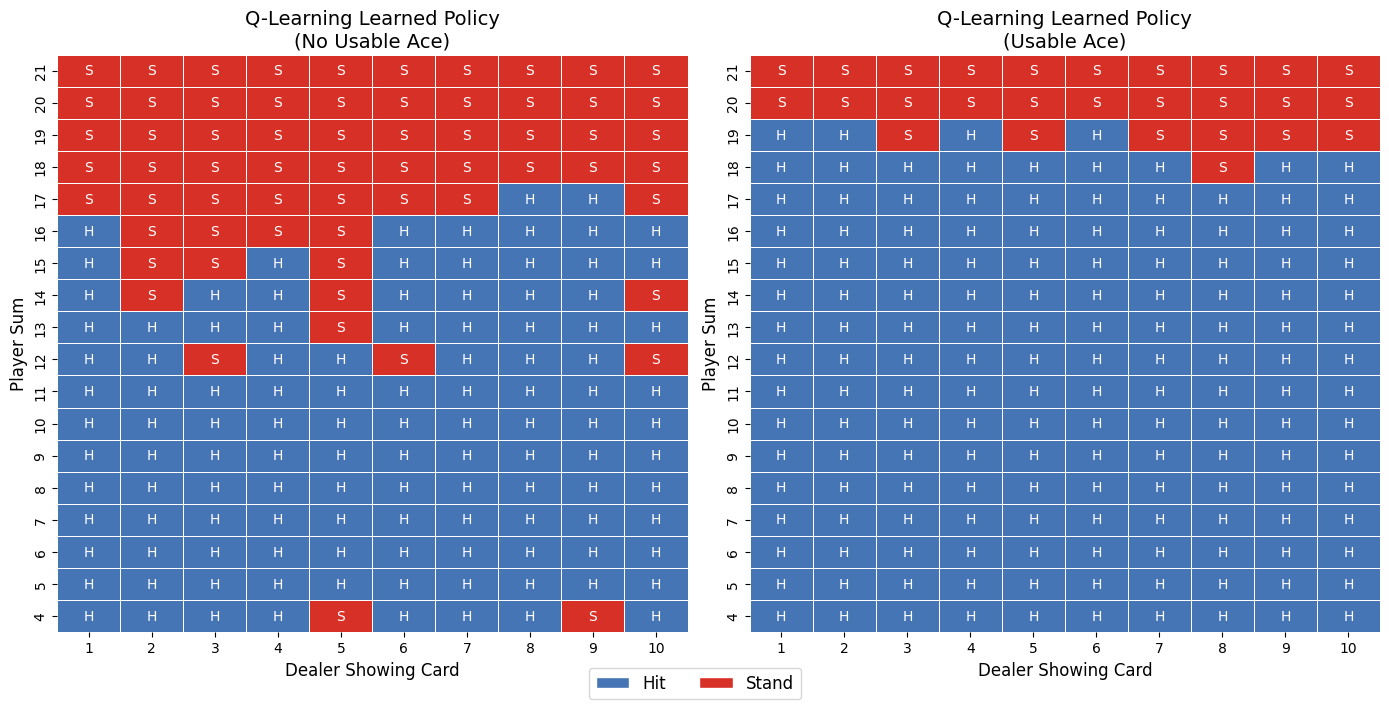

In [22]:
plot_blackjack_policy(ql_Q, title="Q-Learning Learned Policy")

### Qualitative Discussion
- **No Usable Ace (Hard Totals)**: When comparing the learned policies against the Optimal Basic Strategy, both Monte Carlo and Q-Learning accurately discover the core tenets: standing on stiff hands (13–16) against a weak dealer showing card (2–6), hitting on lower sums (4–11), and standing on 17+. Q-Learning captures the exact threshold for hitting on 12 against a dealer 2 or 3 much better than Monte Carlo.
- **Usable Ace (Soft Totals)**: Soft hands appear slightly messier/noisier because they occur far less frequently in regular play. While the Basic Strategy dictates hitting soft 17 and standing on soft 19+, the models struggle to perfectly replicate the soft 18 rule (stand against 2-8, hit against 9, 10, Ace). However, they roughly capture the broader pattern of hitting until 18 and standing on 19+.
- **Conclusion**: Q-Learning often yields a smoother, more defined boundary (especially near the critical 17 threshold for hard totals) because its off-policy TD updates squeeze more value from every transition, allowing it to generalize more efficiently than the end-of-episode backward updates of First-Visit Monte Carlo. Overall, the learned Q-Learning policy remarkably mirrors the mathematically optimal Basic Strategy.

### GenAI disclosure:
* Used genAI to research Monte Carlo and Tabular Q-Learning
* Used genAI when got stuck with python syntax errors
* Used genAI to help with matplotlib plotting
